# Week 12 - Exercise
### Notebook created by Jonathan Penava

In this exercise you are going to build a Tensor Flow model similar to the numbers example, but this time it will try to predict an article of clothing.  fashion_mnist is a similar dataset to what you saw in class, but with clothing.  I have started you with some code.

In [3]:
import tensorflow as ts
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
import tensorflow.keras as tk
fashion_mnist = tk.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
labels=['T-shirt/Top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

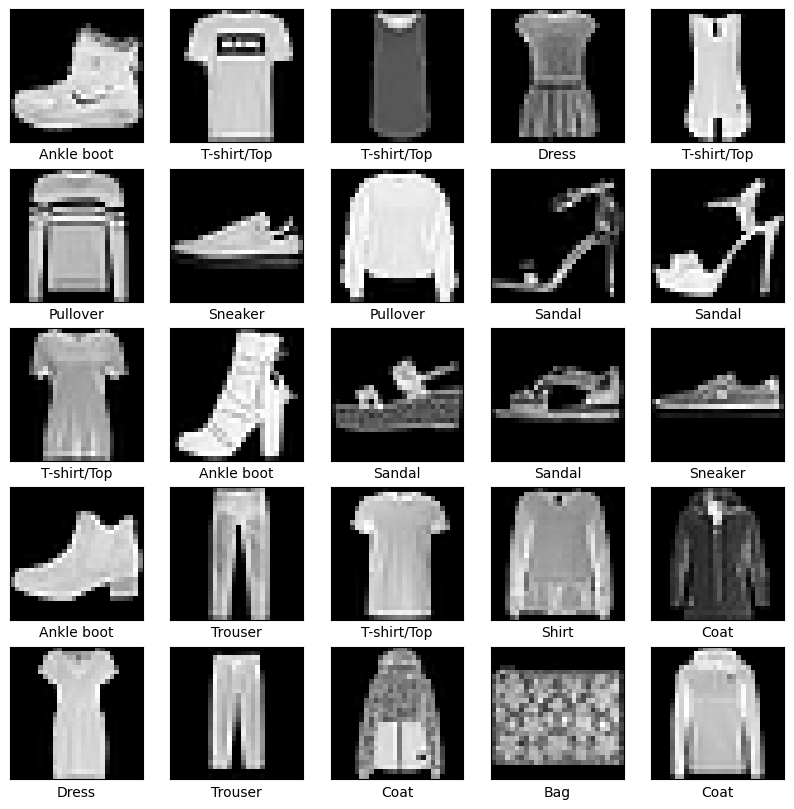

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25): 
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i],cmap='grey')
  plt.xlabel(labels[train_labels[i]])
plt.show()

Complete the model based on what we did in class.  Then, find yourself an image online, and try to have your model predict what it is.  If your model does not predict your image, examine the probability of all the outcomes to see if your model was close.

<span style="color:red;">At the end your model will have picked a number.  To get the name of the clothing item to appear you can use that number as the index in the labels list<br><br>
print(labels[num])
</span>

In [ ]:
x_train = train_images.reshape(60000, 28, 28, 1)
x_test = test_images.reshape(10000, 28, 28, 1)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten

In [ ]:
model = Sequential()

model.add(Conv2D(128,(2,2),activation='relu',input_shape=(28,28,1)))
model.add(Conv2D(64,(2,2),activation='relu'))
model.add(Conv2D(32,(2,2),activation='relu'))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(x_train, train_labels, epochs=5, validation_split=0.1)

In [ ]:
predictions = model.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, predictions.argmax(axis=1)))

In [ ]:
import cv2

file = 'myfashion.png'
testing = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

In [ ]:
plt.imshow(testing, cmap='grey')
plt.show()

In [ ]:
img_resized = cv2.resize(testing, (28,28), interpolation=cv2.INTER_LINEAR)

In [ ]:
img_resized = cv2.resize(testing, (28,28), interpolation=cv2.INTER_LINEAR)

img_resized = cv2.bitwise_not(img_resized)

img_resized = img_resized / 255.0

Xt = img_resized.reshape(1,28,28,1)

In [ ]:
result = model.predict(Xt)
print(result)

In [ ]:
num = result.argmax()
print(num)
print(labels[num])